<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/Clustering_Assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLUSTERING ANALYSIS — EAST-WEST AIRLINES



- Data preprocessing: missing values, outliers and feature scaling
- Exploratory Data Analysis (EDA)
- Multiple visualizations
- K-Means clustering with an elbow curve
- Hierarchical clustering with linkage experiments
- DBSCAN with epsilon/minPts experiments
- Cluster analysis and interpretation
- Visualization of cluster separation
- Silhouette-score evaluation



In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
FILE = "EastWestAirlines.xlsx"

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load the Dataset



In [ ]:
df = pd.read_excel(FILE, sheet_name="data")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (3999, 12)


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


## 2. Understand the Dataset

 preprocessing before clustering, including handling missing values, outliers and scaling.


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe().T)


Column names:
['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']

Data types:


,dtype
ID#,int64
Balance,int64
Qual_miles,int64
cc1_miles,int64
cc2_miles,int64
cc3_miles,int64
Bonus_miles,int64
Bonus_trans,int64
Flight_miles_12mo,int64
Flight_trans_12,int64



Missing values:


,missing
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0



Duplicate rows: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
ID#,3999.000,2014.819,1160.764,1.000,1010.500,2016.000,3020.500,4021.000
Balance,3999.000,73601.328,100775.665,0.000,18527.500,43097.000,92404.000,1704838.000
Qual_miles,3999.000,144.115,773.664,0.000,0.000,0.000,0.000,11148.000
cc1_miles,3999.000,2.060,1.377,1.000,1.000,1.000,3.000,5.000
cc2_miles,3999.000,1.015,0.148,1.000,1.000,1.000,1.000,3.000
cc3_miles,3999.000,1.012,0.195,1.000,1.000,1.000,1.000,5.000
Bonus_miles,3999.000,17144.846,24150.968,0.000,1250.000,7171.000,23800.500,263685.000
Bonus_trans,3999.000,11.602,9.604,0.000,3.000,12.000,17.000,86.000
Flight_miles_12mo,3999.000,460.056,1400.209,0.000,0.000,0.000,311.000,30817.000
Flight_trans_12,3999.000,1.374,3.793,0.000,0.000,0.000,1.000,53.000


## 3. Select Clustering Features

`ID#` and `Award?` are excluded. The remaining numerical variables describe mileage, bonus activity, flight activity and enrollment information.


In [ ]:
features = [c for c in df.columns if c not in ["ID#", "Award?"]]
X = df[features].copy()

print("Clustering features:")
print(features)
display(X.head())


Clustering features:
['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,28143,0,1,1,1,174,1,0,0,7000
1,19244,0,1,1,1,215,2,0,0,6968
2,41354,0,1,1,1,4123,4,0,0,7034
3,14776,0,1,1,1,500,1,0,0,6952
4,97752,0,4,1,1,43300,26,2077,4,6935


## 4. Outlier Treatment and Feature Scaling

Because distance-based clustering can be strongly influenced by extreme observations, the analysis uses 1st/99th percentile winsorization. This reduces the influence of extreme values without deleting customers.

After that, `StandardScaler` puts all variables on a comparable scale.


In [ ]:
X_processed = X.copy()

for col in features:
    low = X_processed[col].quantile(0.01)
    high = X_processed[col].quantile(0.99)
    X_processed[col] = X_processed[col].clip(low, high)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

print("Scaled matrix shape:", X_scaled.shape)
print("Mean of first 5 scaled features:", X_scaled[:, :5].mean(axis=0).round(3))
print("Std of first 5 scaled features:", X_scaled[:, :5].std(axis=0).round(3))


Scaled matrix shape: (3999, 10)
Mean of first 5 scaled features: [ 0. -0.  0.  0.  0.]
Std of first 5 scaled features: [1. 1. 1. 1. 0.]


## 5. Exploratory Data Analysis — Boxplots

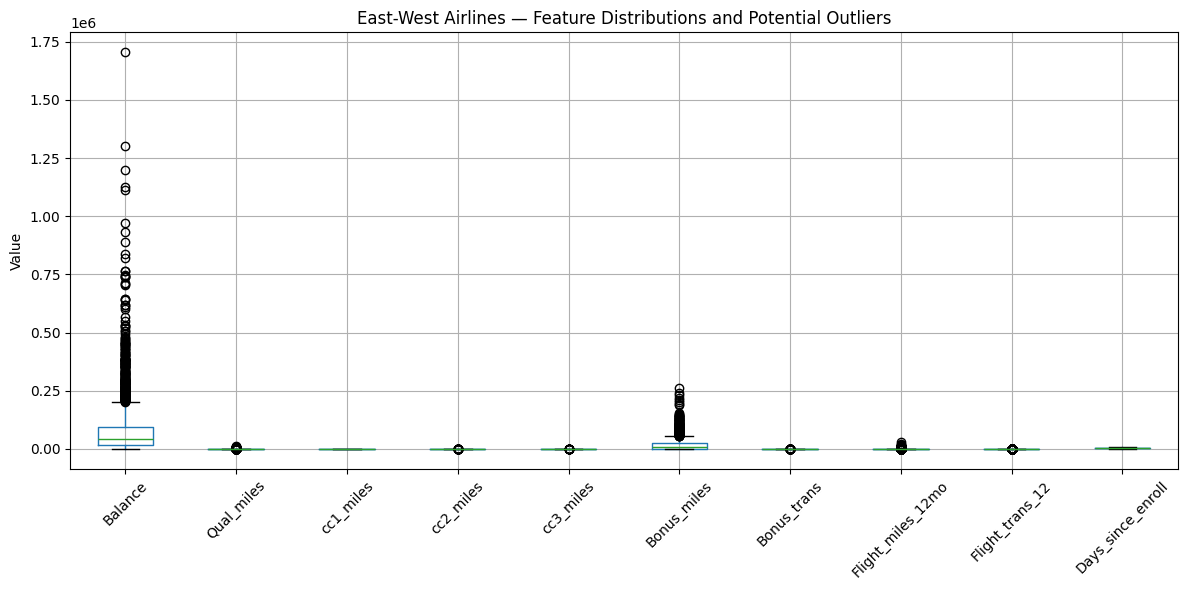

In [ ]:
plt.figure(figsize=(12, 6))
df[features].boxplot(rot=45)
plt.title("East-West Airlines — Feature Distributions and Potential Outliers")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


## 6. Correlation Analysis

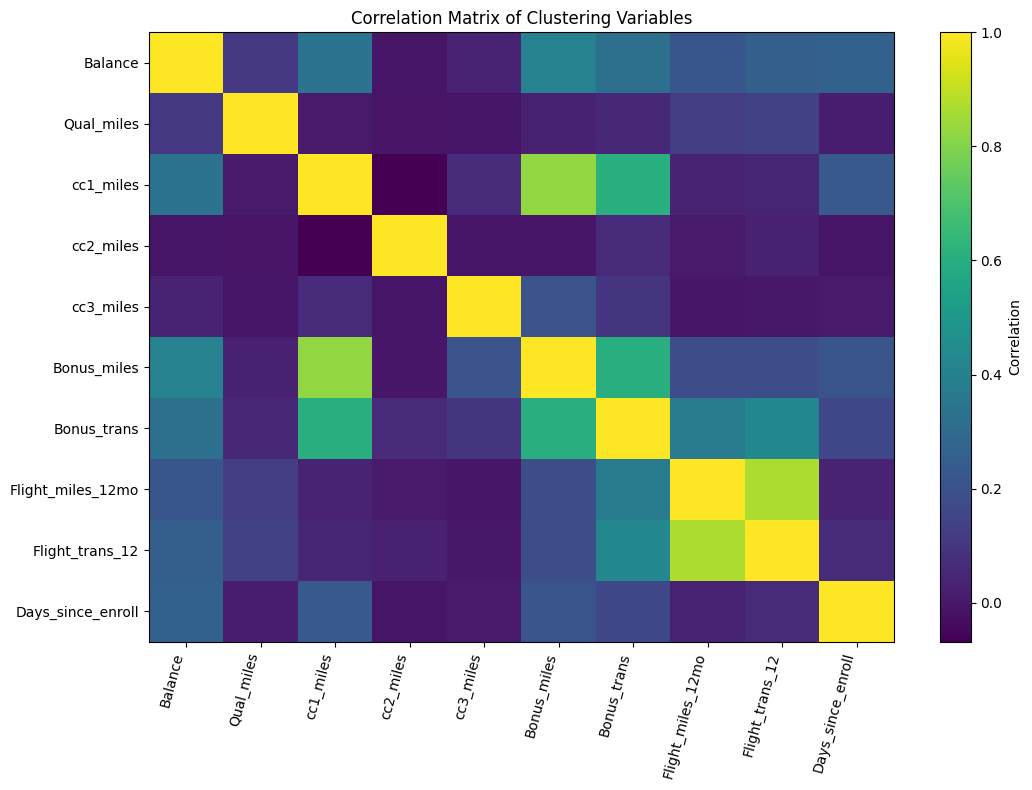

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Balance,1.000,0.110,0.340,-0.010,0.040,0.400,0.320,0.220,0.260,0.260
Qual_miles,0.110,1.000,0.010,-0.010,-0.010,0.030,0.050,0.130,0.140,0.020
cc1_miles,0.340,0.010,1.000,-0.070,0.060,0.830,0.610,0.040,0.040,0.230
cc2_miles,-0.010,-0.010,-0.070,1.000,-0.010,-0.000,0.060,0.010,0.030,-0.010
cc3_miles,0.040,-0.010,0.060,-0.010,1.000,0.200,0.100,-0.000,-0.000,0.010
Bonus_miles,0.400,0.030,0.830,-0.000,0.200,1.000,0.600,0.180,0.190,0.210
Bonus_trans,0.320,0.050,0.610,0.060,0.100,0.600,1.000,0.380,0.430,0.160
Flight_miles_12mo,0.220,0.130,0.040,0.010,-0.000,0.180,0.380,1.000,0.870,0.040
Flight_trans_12,0.260,0.140,0.040,0.030,-0.000,0.190,0.430,0.870,1.000,0.060
Days_since_enroll,0.260,0.020,0.230,-0.010,0.010,0.210,0.160,0.040,0.060,1.000


In [ ]:
corr = df[features].corr()

plt.figure(figsize=(11, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(features)), features, rotation=75, ha="right")
plt.yticks(range(len(features)), features)
plt.title("Correlation Matrix of Clustering Variables")
plt.tight_layout()
plt.show()

display(corr.round(2))


# 7. K-Means Clustering

 **Elbow curve for different K values** and evaluation of the clustering results.


In [ ]:
k_results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    k_results.append([k, model.inertia_, sil])

kdf = pd.DataFrame(k_results, columns=["K", "Inertia", "Silhouette"])
display(kdf)


,K,Inertia,Silhouette
0,2,27472.040,0.355
1,3,22369.003,0.329
2,4,18494.578,0.348
3,5,15767.002,0.365
4,6,13961.074,0.260
5,7,12404.196,0.268
6,8,11471.656,0.273
7,9,10626.737,0.270
8,10,9976.067,0.269


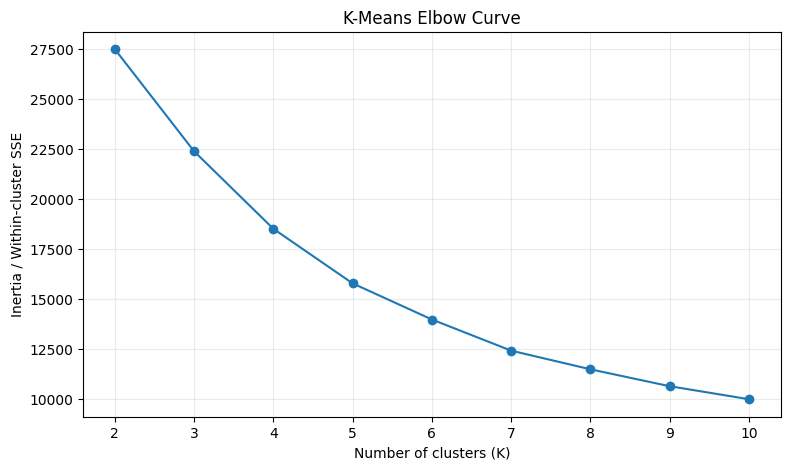

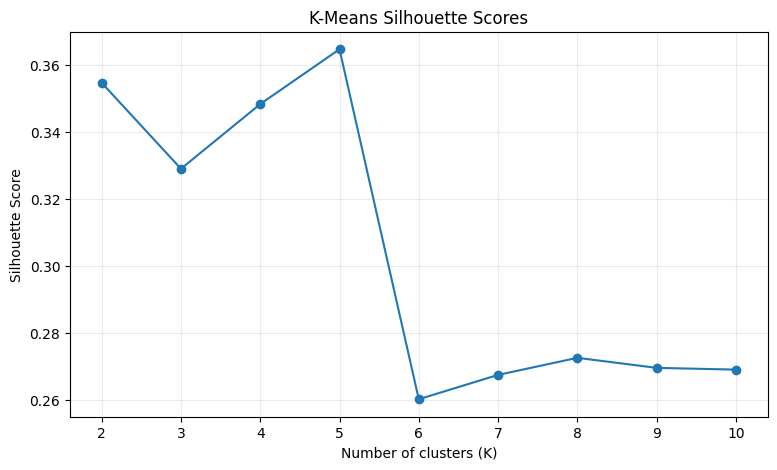

Best K according to silhouette: 5
Main assignment solution: K=5


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(kdf["K"], kdf["Inertia"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia / Within-cluster SSE")
plt.title("K-Means Elbow Curve")
plt.xticks(kdf["K"])
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(kdf["K"], kdf["Silhouette"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.xticks(kdf["K"])
plt.grid(alpha=0.25)
plt.show()

best_k_by_silhouette = int(kdf.loc[kdf["Silhouette"].idxmax(), "K"])
print("Best K according to silhouette:", best_k_by_silhouette)
print("Main assignment solution: K=5")


In [ ]:
K = 5

kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
km_labels = kmeans.fit_predict(X_scaled)
km_silhouette = silhouette_score(X_scaled, km_labels)

print("K-Means K =", K)
print("K-Means Silhouette Score =", round(km_silhouette, 4))
print("\nCluster sizes:")
display(pd.Series(km_labels).value_counts().sort_index().rename("Customers"))


K-Means K = 5
K-Means Silhouette Score = 0.3648

Cluster sizes:


,Customers
0,2357
1,110
2,1270
3,43
4,219


## 8. K-Means Visualization using PCA

Variance explained by PC1: 0.3507
Variance explained by PC2: 0.1937
Total variance explained: 0.5444


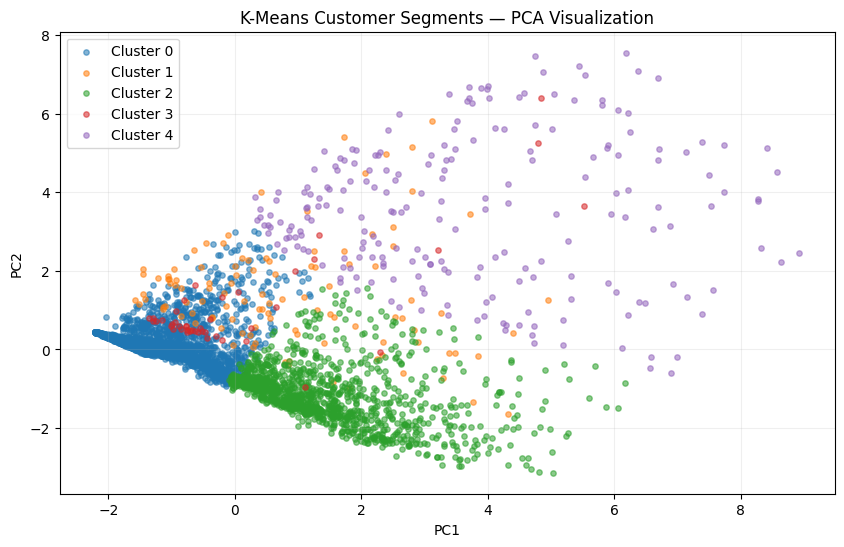

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Variance explained by PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total variance explained:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(10, 6))

for cluster in sorted(np.unique(km_labels)):
    mask = km_labels == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=15,
        alpha=0.55,
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Customer Segments — PCA Visualization")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# 9. Hierarchical Clustering

 hierarchical linkage criteria and evaluate the results.


In [ ]:
hier_results = []

for linkage_name in ["ward", "complete", "average", "single"]:
    for k in range(2, 8):
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage_name
        )
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        hier_results.append([linkage_name, k, sil])

hier_df = pd.DataFrame(
    hier_results,
    columns=["Linkage", "K", "Silhouette"]
)

display(
    hier_df.sort_values("Silhouette", ascending=False).head(15)
)


,Linkage,K,Silhouette
6,complete,2,0.675
12,average,2,0.675
18,single,2,0.675
19,single,3,0.667
20,single,4,0.645
21,single,5,0.644
22,single,6,0.643
23,single,7,0.637
7,complete,3,0.595
13,average,3,0.595


In [ ]:
best_hier = hier_df.sort_values("Silhouette", ascending=False).iloc[0]

hier_linkage = best_hier["Linkage"]
hier_k = int(best_hier["K"])

hier_model = AgglomerativeClustering(
    n_clusters=hier_k,
    linkage=hier_linkage
)

hier_labels = hier_model.fit_predict(X_scaled)
hier_silhouette = silhouette_score(X_scaled, hier_labels)

print("Selected linkage:", hier_linkage)
print("Selected K:", hier_k)
print("Silhouette:", round(hier_silhouette, 4))


Selected linkage: complete
Selected K: 2
Silhouette: 0.6747


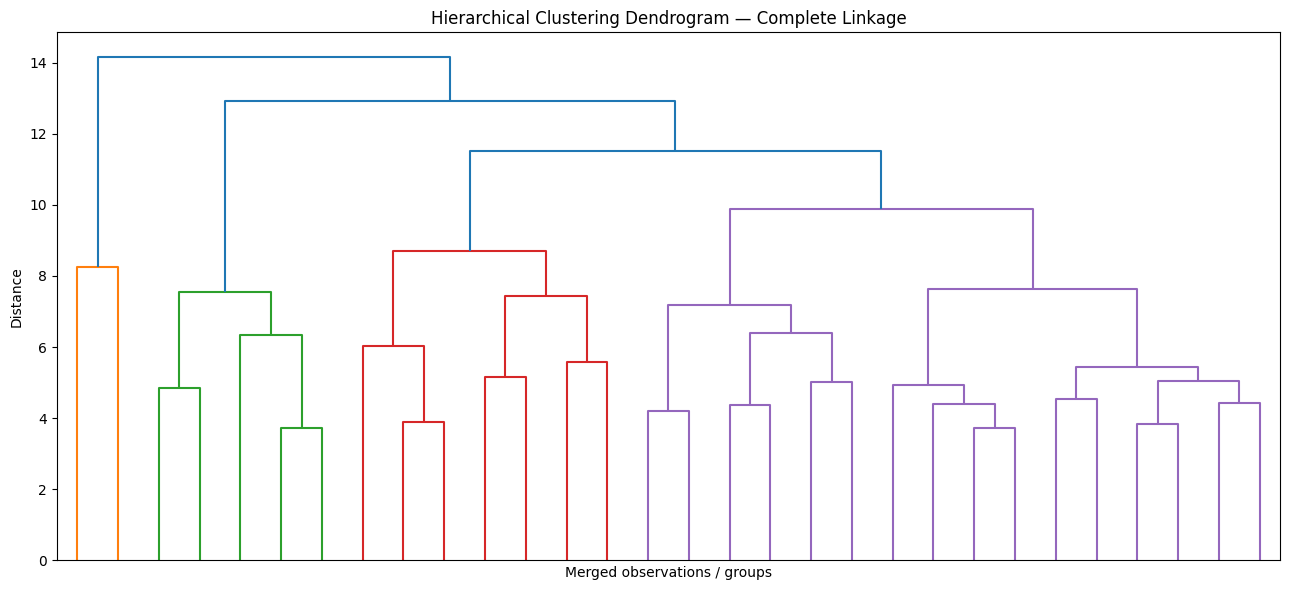

In [ ]:
# Dendrogram on a readable random sample
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(300, len(X_scaled))
sample_indices = rng.choice(len(X_scaled), size=sample_size, replace=False)

Z = linkage(X_scaled[sample_indices], method=hier_linkage)

plt.figure(figsize=(13, 6))
dendrogram(
    Z,
    no_labels=True,
    truncate_mode="lastp",
    p=30
)
plt.title(
    f"Hierarchical Clustering Dendrogram — "
    f"{str(hier_linkage).title()} Linkage"
)
plt.xlabel("Merged observations / groups")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


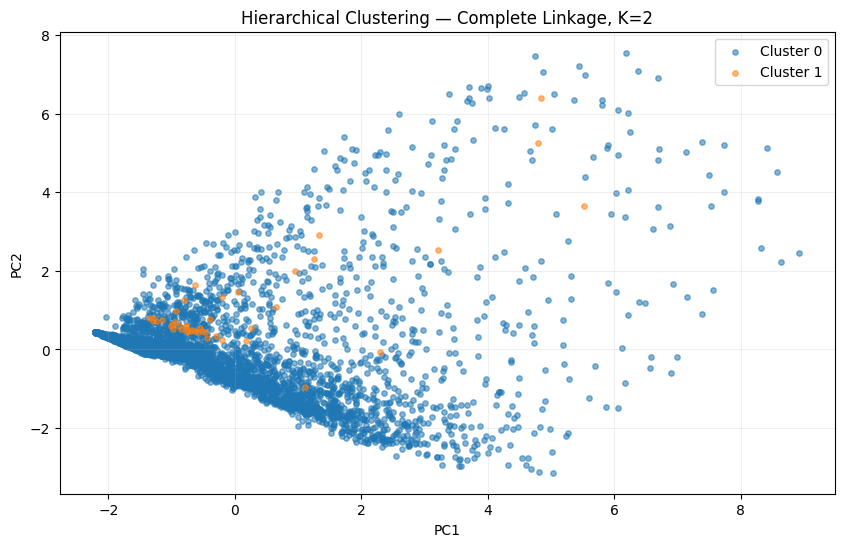

In [ ]:
plt.figure(figsize=(10, 6))

for cluster in sorted(np.unique(hier_labels)):
    mask = hier_labels == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=15,
        alpha=0.55,
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    f"Hierarchical Clustering — {hier_linkage.title()} Linkage, K={hier_k}"
)
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# 10. DBSCAN

 DBSCAN parameters such as **epsilon and minPts**.

In [ ]:
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [5, 10, 20]

db_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        labels = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        ).fit_predict(X_scaled)

        non_noise = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_fraction = (labels == -1).mean()

        if n_clusters >= 2 and non_noise.sum() > 1:
            sil = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise]
            )
        else:
            sil = np.nan

        db_results.append([
            eps,
            min_samples,
            n_clusters,
            noise_fraction,
            sil
        ])

dbdf = pd.DataFrame(
    db_results,
    columns=[
        "Epsilon",
        "Min_samples",
        "Clusters",
        "Noise_fraction",
        "Silhouette"
    ]
)

display(
    dbdf.dropna()
       .sort_values("Silhouette", ascending=False)
       .head(15)
)


,Epsilon,Min_samples,Clusters,Noise_fraction,Silhouette
16,0.800,10,2,0.223,0.762
19,0.900,10,2,0.192,0.756
22,1.000,10,2,0.164,0.748
26,1.200,20,2,0.147,0.744
25,1.200,10,2,0.126,0.737
29,1.500,20,2,0.107,0.731
32,2.000,20,2,0.053,0.706
31,2.000,10,2,0.040,0.697
30,2.000,5,3,0.030,0.610
27,1.500,5,4,0.060,0.603


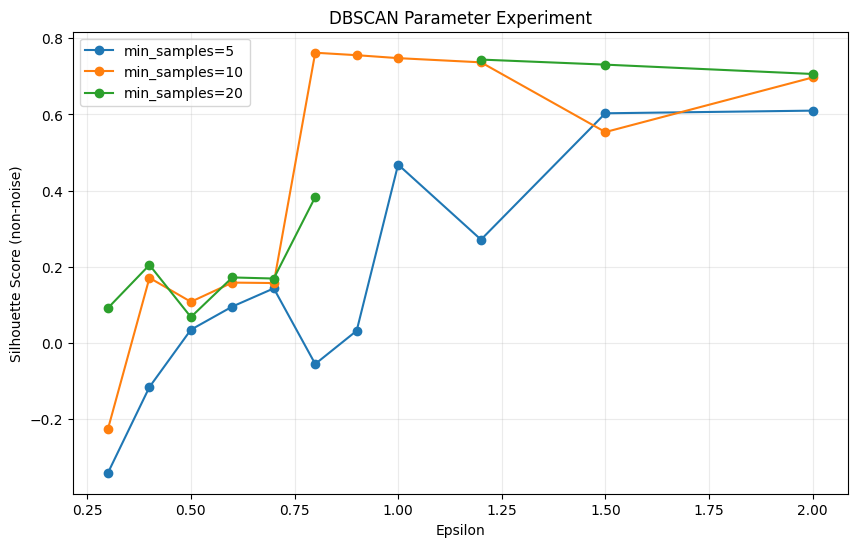

In [ ]:
plt.figure(figsize=(10, 6))

for ms in min_samples_values:
    temp = dbdf[dbdf["Min_samples"] == ms]
    plt.plot(
        temp["Epsilon"],
        temp["Silhouette"],
        marker="o",
        label=f"min_samples={ms}"
    )

plt.xlabel("Epsilon")
plt.ylabel("Silhouette Score (non-noise)")
plt.title("DBSCAN Parameter Experiment")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [ ]:
best_db = (
    dbdf.dropna(subset=["Silhouette"])
        .sort_values("Silhouette", ascending=False)
        .iloc[0]
)

db_eps = float(best_db["Epsilon"])
db_min_samples = int(best_db["Min_samples"])

dbscan = DBSCAN(
    eps=db_eps,
    min_samples=db_min_samples,
    n_jobs=-1
)

db_labels = dbscan.fit_predict(X_scaled)

db_non_noise = db_labels != -1
db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
db_noise_fraction = (db_labels == -1).mean()

if db_clusters >= 2:
    db_silhouette = silhouette_score(
        X_scaled[db_non_noise],
        db_labels[db_non_noise]
    )
else:
    db_silhouette = np.nan

print("Selected DBSCAN epsilon:", db_eps)
print("Selected min_samples:", db_min_samples)
print("Number of clusters:", db_clusters)
print("Noise percentage:", round(db_noise_fraction * 100, 2), "%")
print("DBSCAN silhouette (non-noise):", round(db_silhouette, 4))


Selected DBSCAN epsilon: 0.8
Selected min_samples: 10
Number of clusters: 2
Noise percentage: 22.26 %
DBSCAN silhouette (non-noise): 0.7621


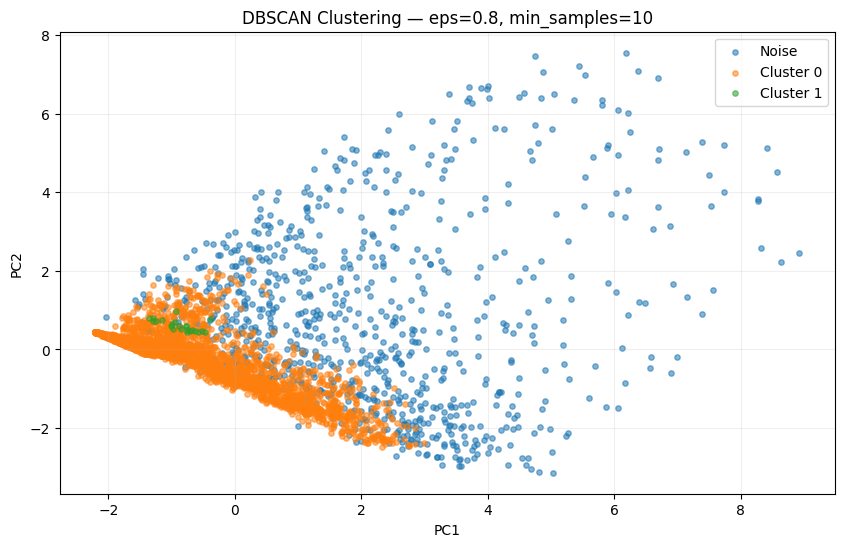

In [ ]:
plt.figure(figsize=(10, 6))

for cluster in sorted(np.unique(db_labels)):
    mask = db_labels == cluster
    name = "Noise" if cluster == -1 else f"Cluster {cluster}"

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=15,
        alpha=0.55,
        label=name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    f"DBSCAN Clustering — eps={db_eps}, min_samples={db_min_samples}"
)
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# 11. Cluster Profiles

 analysis and interpretation of the characteristics of each generated cluster.


In [ ]:
def cluster_profile(labels):
    temp = df[features].copy()
    temp["Cluster"] = labels

    means = temp.groupby("Cluster")[features].mean().round(1)
    counts = temp["Cluster"].value_counts().sort_index()

    profile = means.copy()
    profile.insert(0, "Customers", counts)
    profile.insert(
        1,
        "Percentage",
        (counts / len(temp) * 100).round(2)
    )

    return profile

print("K-Means cluster profile")
km_profile = cluster_profile(km_labels)
display(km_profile)

print("Hierarchical cluster profile")
hier_profile = cluster_profile(hier_labels)
display(hier_profile)

print("DBSCAN cluster profile")
db_profile = cluster_profile(db_labels)
display(db_profile)


K-Means cluster profile


,Customers,Percentage,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Cluster,,,,,,,,,,,,
0,2357,58.940,40171.200,16.700,1.200,1.000,1.000,4134.100,6.500,162.900,0.500,3693.100
1,110,2.750,97507.700,3896.000,2.000,1.000,1.000,18368.000,11.600,654.400,2.000,4044.200
2,1270,31.760,116177.200,20.900,3.700,1.000,1.000,38467.400,18.400,253.000,0.800,4848.100
3,43,1.080,68876.600,23.300,1.100,2.300,1.000,14689.800,17.500,582.600,2.200,3968.900
4,219,5.480,175413.900,369.100,2.300,1.000,1.000,33390.400,25.800,4737.400,13.500,4533.600


Hierarchical cluster profile


,Customers,Percentage,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Cluster,,,,,,,,,,,,
0,3956,98.920,73652.700,145.400,2.100,1.000,1.000,17171.500,11.500,458.700,1.400,4120.200
1,43,1.080,68876.600,23.300,1.100,2.300,1.000,14689.800,17.500,582.600,2.200,3968.900


DBSCAN cluster profile


,Customers,Percentage,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Cluster,,,,,,,,,,,,
-1,890,22.260,156358.900,647.500,2.700,1.000,1.100,35414.300,19.900,1721.600,5.000,4649.600
0,3086,77.170,50042.000,0.000,1.900,1.000,1.000,11927.600,9.200,99.500,0.300,3969.600
1,23,0.580,32285.400,0.000,1.000,2.300,1.000,10220.700,12.900,17.400,0.100,3553.000


# 12. Cluster Interpretation

### K-Means
The K-Means solution separates customers into five groups with different combinations of balance, bonus activity, qualifying miles and recent flight activity.

- **Lower-engagement segment:** relatively lower balance and activity.
- **Qualifying-mile segment:** customers with high qualifying-mile activity.
- **Long-tenure/high-balance segment:** customers with accumulated balance and longer enrollment.
- **Active-traveler segment:** customers with comparatively higher flight transactions.
- **High-engagement segment:** customers showing strong balance and recent flight activity.

### Hierarchical Clustering
The hierarchical solution provides a different grouping structure and is useful for examining how customers merge as the clustering distance increases.

### DBSCAN
DBSCAN identifies dense groups and labels observations outside the dense regions as **noise**. These noise observations can be especially interesting because they may represent unusual or highly active customers.

The exact numerical characteristics should be read from the cluster-profile tables above rather than inferred from the visualization alone.


# 13. Evaluation Summary

In [ ]:
evaluation = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Parameters": [
        f"K={K}",
        f"{hier_linkage}, K={hier_k}",
        f"eps={db_eps}, min_samples={db_min_samples}"
    ],
    "Clusters": [
        len(np.unique(km_labels)),
        len(np.unique(hier_labels)),
        db_clusters
    ],
    "Silhouette": [
        km_silhouette,
        hier_silhouette,
        db_silhouette
    ]
})

display(evaluation.round(4))


,Algorithm,Parameters,Clusters,Silhouette
0,K-Means,K=5,5,0.365
1,Hierarchical,"complete, K=2",2,0.675
2,DBSCAN,"eps=0.8, min_samples=10",2,0.762


# 14. Final Conclusion

The East-West Airlines customer dataset contains meaningful differences in customer mileage, bonus activity, flight activity and enrollment duration.

After preprocessing and standardization, three clustering approaches were applied:

1. **K-Means** provides a practical five-segment customer view.
2. **Hierarchical clustering** reveals how groups are formed through successive merges and allows comparison of different linkage strategies.
3. **DBSCAN** identifies dense customer groups while also detecting observations that do not fit those dense groups.

Silhouette scores are used as an internal evaluation metric.

Overall, the three methods provide complementary views of the customer population. K-Means is particularly convenient for actionable segmentation, while DBSCAN is valuable when unusual customer behavior and noise/outliers are important.
